# Text Query Label Predictor

This notebook presents a solution for a Kaggle competition focused on multiclass text query classification.

The project addresses several key challenges:

- Handling severe class imbalance through undersampling and class weighting.
- Cleaning and preprocessing raw text queries by removing noise, punctuation, and special characters.
- Transforming textual data into numerical representations using TF-IDF vectorization.
- Building and evaluating a Logistic Regression model for accurate intent classification.
- Visualizing model performance using classification reports and confusion matrices.

An interactive Gradio interface is also developed to allow real-time query classification.

## Importing essential libraries like pandas, numpy, matplotlib, and seaborn for data handling and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Loading the training and testing datasets from CSV files into pandas DataFrames.

In [4]:
df_train = pd.read_csv('/content/train (1).csv')
df_test = pd.read_csv('/content/test (1).csv')

##Displaying the first few rows of the training data to get a quick overview of its structure.

In [5]:
df_train.head()

,query,label
0,what expression would i use to say i love you ...,other
1,can you tell me how to say 'i do not speak muc...,other
2,"what is the equivalent of, 'life is good' in f...",other
3,"tell me how to say, 'it is a beautiful morning...",other
4,"if i were mongolian, how would i say that i am...",other


## Checking the data types and non-null counts of columns in the training DataFrame.

In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15100 entries, 0 to 15099
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   query   15100 non-null  object
 1   label   15100 non-null  object
dtypes: object(2)
memory usage: 236.1+ KB


##Counting any missing values in each column of the training data.

In [7]:
df_train.isnull().sum()

,0
query,0
label,0


##Generating descriptive statistics for the training data, revealing initial insights into label distribution and class imbalance.

In [8]:
df_train.describe()

,query,label
count,15100,15100
unique,15100,8
top,what's the average battery life of an android ...,other
freq,1,14400


##Analyzing the count of each unique label, confirming a significant class imbalance where 'other' is dominant.

In [9]:
df_train['label'].value_counts()

,count
label,
other,14400
transfer,100
balance,100
freeze_account,100
transactions,100
pay_bill,100
report_lost_card,100
out-of-scope,100


##Undersampling the 'other' (majority) class to reduce its count and address the class imbalance problem.

In [10]:
other = df_train[df_train['label'] == 'other'].sample(n=400)

##Combining the undersampled 'other' class with minority classes and shuffling the entire training DataFrame for balanced learning.

In [11]:
rest_df = df_train[df_train['label'] != 'other']
df_train = pd.concat([rest_df, other], ignore_index=True)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

## Re-checking the label distribution after undersampling to confirm better balance among classes.

In [12]:
df_train['label'].value_counts()

,count
label,
other,400
transactions,100
out-of-scope,100
pay_bill,100
freeze_account,100
transfer,100
balance,100
report_lost_card,100


##Visualizing the label distribution using a count plot to graphically confirm the improved class balance.

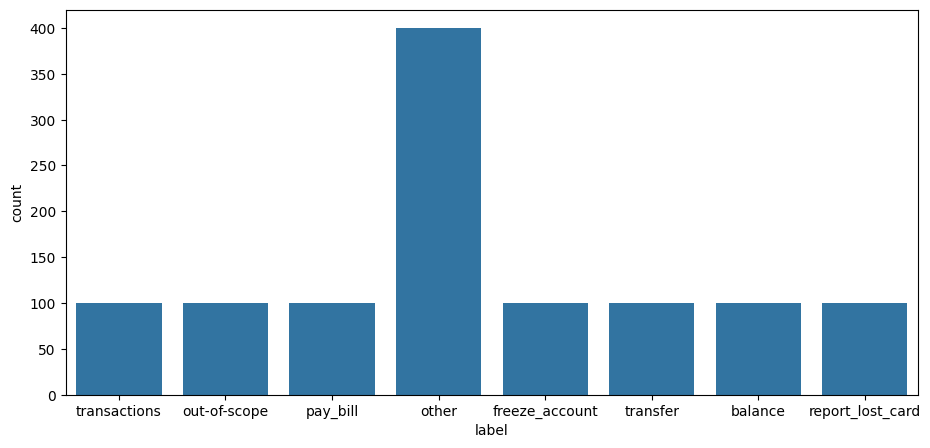

In [13]:
plt.figure(figsize=(11,5))
sns.countplot(x=df_train['label'])
plt.show()

##Defining and applying a `clean_text` function to preprocess text queries in the training data (lowercasing, removing punctuation, etc.).

In [14]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = ' '.join(text.split())
    return text

df_train['clean_query'] = df_train['query'].apply(clean_text)

##Applying the same `clean_text` function to the test data to ensure consistent preprocessing.

In [15]:
df_test['clean_query'] = df_test['query'].apply(clean_text)

##Comparing original and cleaned queries to verify the effectiveness of the text cleaning process.

In [16]:
df_train[['query','clean_query']].head(10)

,query,clean_query
0,please tell me my in-person transactions for t...,please tell me my inperson transactions for th...
1,what year was star trek released,what year was star trek released
2,i need help paying my auto insurance bill,i need help paying my auto insurance bill
3,can you tell me what you think the meaning of ...,can you tell me what you think the meaning of ...
4,i need to hold off on my account,i need to hold off on my account
5,how many miles can i drive before i need to ch...,how many miles can i drive before i need to ch...
6,deposit ten bucks from my chase account to my ...,deposit ten bucks from my chase account to my ...
7,how is glue made,how is glue made
8,what is the due date for a bill,what is the due date for a bill
9,check chase bank for my checking balance,check chase bank for my checking balance


##Initializing a `TfidfVectorizer` to convert text into numerical features, capturing relevant words and phrases.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,3),
    min_df=2
)


##Transforming training and test queries into TF-IDF numerical matrices for model input. Ensures consistent feature representation.

In [18]:
X_train_tfidf = tfidf.fit_transform(df_train['clean_query'])
X_test_tfidf = tfidf.transform(df_test['clean_query'])

print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

Shape of X_train_tfidf: (1100, 2073)
Shape of X_test_tfidf: (8600, 2073)


##Converting categorical labels into numerical format using `LabelEncoder` for model compatibility.

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_train['label_encoded'] = le.fit_transform(df_train['label'])

print(le.classes_)

['balance' 'freeze_account' 'other' 'out-of-scope' 'pay_bill'
 'report_lost_card' 'transactions' 'transfer']


##Splitting the data into training and validation sets, using stratified sampling to maintain class proportions.

In [20]:
from sklearn.model_selection import train_test_split

X = df_train['clean_query']
y = df_train['label_encoded']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

##Training a Logistic Regression model on the TF-IDF features, using `class_weight='balanced'` to handle remaining imbalance.

In [21]:
from sklearn.linear_model import LogisticRegression

X_train_tfidf_split = tfidf.transform(X_train)
X_val_tfidf_split = tfidf.transform(X_val)

print(f"Shape of X_train_tfidf_split: {X_train_tfidf_split.shape}")
print(f"Shape of X_val_tfidf_split: {X_val_tfidf_split.shape}")

model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_tfidf_split, y_train)

Shape of X_train_tfidf_split: (880, 2073)
Shape of X_val_tfidf_split: (220, 2073)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

##Generating a classification report to evaluate model performance (precision, recall, f1-score) for each class on the validation set.

In [22]:
from sklearn.metrics import classification_report
pred = model.predict(X_val_tfidf_split)
print(classification_report(y_val, pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97        20
           1       0.95      0.95      0.95        20
           2       0.90      0.80      0.85        80
           3       0.62      0.75      0.68        20
           4       0.91      1.00      0.95        20
           5       0.95      1.00      0.98        20
           6       0.87      1.00      0.93        20
           7       0.95      0.95      0.95        20

    accuracy                           0.89       220
   macro avg       0.89      0.93      0.91       220
weighted avg       0.90      0.89      0.89       220



##Visualizing the confusion matrix to show correct and incorrect predictions, helping identify specific class misclassifications.

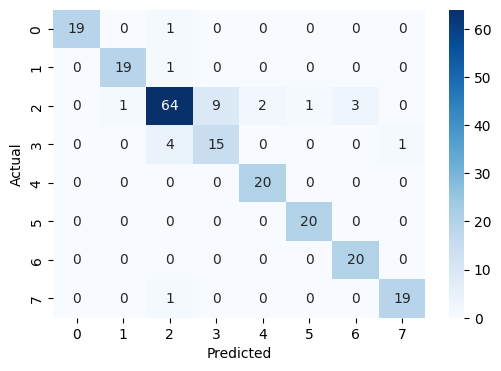

In [23]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_val, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##Importing additional evaluation metrics for further, more specific performance analysis if needed.

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

##Defines a helper function `predict_label` that cleans, vectorizes, and predicts the label for a given text query.

In [25]:
def predict_label(query, model, vectorizer, label_encoder=None):
    """
    Predict label for a given text query.
    """

    query_vector = vectorizer.transform([query])

    pred = model.predict(query_vector)

    if label_encoder:
        pred = label_encoder.inverse_transform(pred)

    return pred[0]

##Demonstrates `predict_label` with an example query to show the model's end-to-end prediction process.

In [28]:
query = "my card is stolen what should i do  "

label = predict_label(
    query=query,
    model=model,
    vectorizer=tfidf,
    label_encoder=le
)

print("Predicted Disease:", label)

Predicted Disease: report_lost_card


##Installs or updates the Gradio library to create an interactive web interface for the model.

In [29]:
pip install --upgrade gradio

##Builds and launches a Gradio web interface, allowing users to interact with the text query label predictor via a simple input box.

In [31]:
import gradio as gr

def classify_query(input_query):
    predicted_label = predict_label(query=input_query, model=model, vectorizer=tfidf, label_encoder=le)
    return predicted_label

demo = gr.Interface(
    fn=classify_query,
    inputs=gr.Textbox(lines=2, placeholder="Enter your query here..."),
    outputs="text",
    title="Text Query Label Predictor"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a8f992ee0f57567ef5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
